## Import packages

In [7]:
import muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# import tensorflow as tf
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# tf.get_logger().setLevel('ERROR')
np.random.seed(0)

In [8]:
# 读取数据
data_path = '/home/lqr/CLIMA/code/data/'
sc = np.load(data_path + '/sc_data.npz')
st = np.load(data_path + '/st_data.npz')

# sc_data = [sc[key] for key in sc.files]
# st_data = [st[key] for key in st.files]
sc_data = [sc['sc_gene'], sc['sc_atac']]

## Generate simulation data


Simulation parameters

In [13]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [10]:
# data = simulation.multi_modal_simulator(
#     num_cluster,
#     sample_size,
#     observed_data_dim,
#     observed_data_dim,
#     latent_code_dim,
#     sigma_1,
#     sigma_2,
#     decay_coef_1,
#     decay_coef_2,
#     merge_prob,
# )
# data_a = data["data_a_dropout"]
# data_b = data["data_b_dropout"]
# label_a = data["data_a_label"]
# label_b = data["data_b_label"]
# label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [14]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(sc_data[0])
view_b_feature = PCA(n_components=latent_dim).fit_transform(sc_data[1])

In [15]:
print(f"sc_data[0].shape: {sc_data[0].shape}")
print(f"sc_data[1].shape: {sc_data[1].shape}")
print(f"view_a_feature.shape: {view_a_feature.shape}")
print(f"view_b_feature.shape: {view_b_feature.shape}")

sc_data[0].shape: (3293, 15782)
sc_data[1].shape: (3293, 15782)
view_a_feature.shape: (3293, 100)
view_b_feature.shape: (3293, 100)


Perform clustering using PhenoGraph

In [16]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10697579383850098 seconds
Jaccard graph constructed in 0.24887847900390625 seconds
Wrote graph to binary file in 0.016050338745117188 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.794227
After 2 runs, maximum modularity is Q = 0.796181
After 3 runs, maximum modularity is Q = 0.797868
Louvain completed 23 runs in 0.9781615734100342 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.5116798877716064 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07871627807617188 seconds
Jaccard graph constructed in 0.22068381309509277 seconds
Wrote graph to binary file in 0.020535707473754883 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.501068
After 2 runs, maximum modularity is Q = 0.511528
Louvain completed 22 runs in 0.90913391113281

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [18]:
muse_feature, reconstruct_x, reconstruct_y, latent_x, latent_y = muse.muse_fit_predict(
    sc_data[0],
    sc_data[1],
    view_a_label,
    view_b_label,
    latent_dim=100,
    n_epochs=500,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ MUSE for multi-modality single-cell analysis ++++++++++
epoch: 0, 	 total loss: 735.99249,	 reconstruction loss: 30.68928,	 sparse penalty: 141.06064
epoch: 50, 	 total loss: 599.39612,	 reconstruction loss: 27.11894,	 sparse penalty: 114.45544
epoch: 100, 	 total loss: 482.10764,	 reconstruction loss: 26.81919,	 sparse penalty: 91.05769
epoch: 150, 	 total loss: 380.19260,	 reconstruction loss: 26.36619,	 sparse penalty: 70.76528
epoch: 0, 	 total loss: 338.44208,	 reconstruction loss: 27.50547,	 sparse penalty: 53.60293,	 x triplet: 4.26881,	 y triplet: 4.31559
epoch: 50, 	 total loss: 261.28427,	 reconstruction loss: 27.22593,	 sparse penalty: 39.77072,	 x triplet: 3.55995,	 y triplet: 3.48100
epoch: 100, 	 total loss: 206.72047,	 reconstruction loss: 27.11543,	 sparse penalty: 28.86412,	 x triplet: 3.57670,	 y triplet: 3.48018
epoch: 150, 	 total loss: 163.84219,	 reconstruction loss: 26.89077,	 sparse penalty: 20.31056,	 x triplet: 3.63387,	 y triplet: 3.44586
Finding 3

## Perform clustering
PhenoGraph clustering

In [19]:
muse_label, _, _ = phenograph.cluster(muse_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08361196517944336 seconds
Jaccard graph constructed in 0.5468871593475342 seconds
Wrote graph to binary file in 0.012203216552734375 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.970117
Louvain completed 21 runs in 1.1005949974060059 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.1691999435424805 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

view_a_feature: (3293, 100)
X_embedded: (3293, 2)


NameError: name 'label_true' is not defined

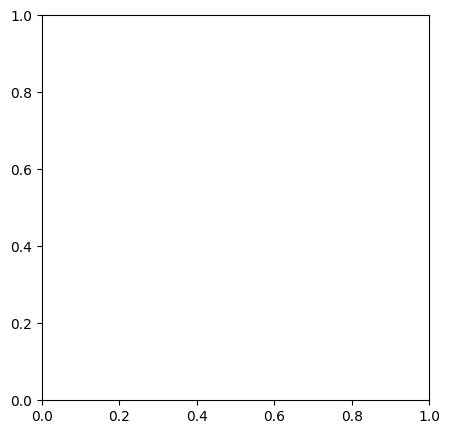

In [20]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 3, 1)
print(f"view_a_feature: {view_a_feature.shape}")
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
print(f"laber_true == i: {(label_true == 0).shape}")
print(f"np.nonzero(label_true == i): {len(np.nonzero(label_true == 2)[0])}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Transcript-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(1, 3, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Morphology-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(1, 3, 3)
X_embedded = TSNE(n_components=2).fit_transform(muse_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label))